In [1]:
from glasflow import RealNVP
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import torch

torch.manual_seed(1451)
np.random.seed(1451)
sns.set_context("notebook")
sns.set_palette("colorblind")

In [6]:
device = torch.device("cpu")
bounds = np.array([[-10, 10], [-10, 10]])
bounds = torch.from_numpy(bounds).to(device)
log_abs_det_jacobian = -torch.log(
            bounds[:, 1] - bounds[:, 0]
        ).sum()

In [7]:
def fit(x: torch.Tensor) -> torch.Tensor:
        """Fit the transform to the data.
        For now, this just applies the transform.
        """
        return forward(x)[0]
def forward(x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        return (
            (x - bounds[..., 0]) / (bounds[..., 1] - bounds[..., 0]),
            log_abs_det_jacobian
            * torch.ones(x.shape[0], device=x.device, dtype=x.dtype),)
def fit_data_transform(x: torch.Tensor) -> torch.Tensor:
        """Fit the data transform to the data."""
        return fit(x)

In [8]:
x= [[7, 8], [5, 4], [5, 6],[7,4],[9,5],[10,3],[4,2]]
y = [[-2,-2], [-3,-2], [-4,-1]]
validation_fraction = 0.2

In [9]:
device = torch.device("cpu")
x = torch.tensor(x, dtype=torch.get_default_dtype(), device=device)
y = torch.tensor(y, dtype=torch.get_default_dtype(), device=device)

In [10]:
print(x)
print(y)

tensor([[ 7.,  8.],
        [ 5.,  4.],
        [ 5.,  6.],
        [ 7.,  4.],
        [ 9.,  5.],
        [10.,  3.],
        [ 4.,  2.]])
tensor([[-2., -2.],
        [-3., -2.],
        [-4., -1.]])


In [11]:
x_prime = fit_data_transform(x)
y_prime = fit_data_transform(y)
print(x_prime, y_prime)

tensor([[0.8500, 0.9000],
        [0.7500, 0.7000],
        [0.7500, 0.8000],
        [0.8500, 0.7000],
        [0.9500, 0.7500],
        [1.0000, 0.6500],
        [0.7000, 0.6000]]) tensor([[0.4000, 0.4000],
        [0.3500, 0.4000],
        [0.3000, 0.4500]])


In [12]:
cx = torch.zeros((x_prime.shape[0], 1), dtype=torch.get_default_dtype(), device=device)
cy = torch.ones((y_prime.shape[0], 1), dtype=torch.get_default_dtype(), device=device)
print(cx,cy)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]]) tensor([[1.],
        [1.],
        [1.]])


In [13]:
z_prime = torch.cat([x_prime, y_prime], dim=0)
c_prime = torch.cat([cx, cy], dim=0)
print(z_prime,c_prime)

tensor([[0.8500, 0.9000],
        [0.7500, 0.7000],
        [0.7500, 0.8000],
        [0.8500, 0.7000],
        [0.9500, 0.7500],
        [1.0000, 0.6500],
        [0.7000, 0.6000],
        [0.4000, 0.4000],
        [0.3500, 0.4000],
        [0.3000, 0.4500]]) tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.]])


In [14]:
indices = torch.randperm(z_prime.shape[0], device=device)
print(indices)
z_prime = z_prime[indices]
c_prime = c_prime[indices]
print(z_prime,c_prime)

tensor([7, 3, 1, 0, 5, 4, 6, 8, 2, 9])
tensor([[0.4000, 0.4000],
        [0.8500, 0.7000],
        [0.7500, 0.7000],
        [0.8500, 0.9000],
        [1.0000, 0.6500],
        [0.9500, 0.7500],
        [0.7000, 0.6000],
        [0.3500, 0.4000],
        [0.7500, 0.8000],
        [0.3000, 0.4500]]) tensor([[1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.]])


In [15]:
n = z_prime.shape[0]
print(n)
n_train = n - int(validation_fraction * n)
print(n_train)
z_train, z_val = z_prime[:n_train], z_prime[n_train:]
c_train, c_val = c_prime[:n_train], c_prime[n_train:]
print(z_train, c_train)
print(z_val, c_val)

10
8
tensor([[0.4000, 0.4000],
        [0.8500, 0.7000],
        [0.7500, 0.7000],
        [0.8500, 0.9000],
        [1.0000, 0.6500],
        [0.9500, 0.7500],
        [0.7000, 0.6000],
        [0.3500, 0.4000]]) tensor([[1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.]])
tensor([[0.7500, 0.8000],
        [0.3000, 0.4500]]) tensor([[0.],
        [1.]])


In [16]:
batch_size = 2
dataset = torch.utils.data.DataLoader(
                torch.utils.data.TensorDataset(z_train, c_train),
                shuffle=False, batch_size=batch_size,
        )
val_dataset = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(z_val, c_val),
            shuffle=False, batch_size=batch_size,
        )

In [17]:
import glasflow.flows as gf
flow_class = "CouplingNSF"
FlowClass = getattr(gf, flow_class, None)
if FlowClass is None:
            raise ValueError(f"Unknown flow class: {flow_class}")

flow = FlowClass(
            n_conditional_inputs=1,
            n_inputs=2,
            n_transforms = 4,
        )
lr = 1e-3

In [18]:
optimizer = torch.optim.Adam(flow.parameters(), lr=lr)

In [19]:
import tqdm

n_epochs=10

In [20]:
def in_bounds( x):
        below_lower = (x < bounds[:,0]).any(-1)
        above_upper = (x > bounds[:,1]).any(-1)
        out = below_lower | above_upper
        return ~ out
def loss_fn(conditions: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """Loss function to minimize."""
        return -flow.log_prob(x, conditional=conditions).mean()
def log_prob(x: np.ndarray, conditional: np.ndarray) -> np.ndarray:
        """Compute the log probability of the data under the model.
        Parameters
        ----------
        x: np.ndarray
            The data to compute the log probability for. Shape should be (n_samples, dims).
        Returns
        -------
        log_prob: np.ndarray
            The log probability of the data under the model. Shape is (n_samples,).
        """
        # Make sure the model is in eval mode
        if flow.training:
            flow.eval()
        # Disable gradients to speed up computation
        with torch.no_grad():
            # Convert to torch tensor and move to device
            x = torch.tensor(x,dtype=torch.get_default_dtype()).to(self.device)
            c = torch.tensor(conditions, dtype=torch.get_default_dtype(), device=self.device)
            log_prob = torch.full((len(x),),-torch.inf)
            in_bounds = data_transform.in_bounds(x)
            if not torch.any(in_bounds):
                return log_prob.cpu().numpy()
            # Transform to unit hypercube
            x_prime, log_abs_det_jacobian = data_transform.forward(x[in_bounds])
            c_in = c[in_bounds]
            # Compute log probability
            log_prob[in_bounds] = flow.log_prob(x_prime, conditional=c_in) + log_abs_det_jacobian
    
        # Return as numpy array
        return log_prob.cpu().numpy()

In [21]:
history = {"training_loss": [], "validation_loss": []}
for _ in tqdm.tqdm(range(n_epochs)):
        flow.train()
        loss_epoch = 0.0
        for z_batch, c_batch in dataset:
            loss = loss_fn(conditions=c_batch, x=z_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_epoch += loss.item()
        history["training_loss"].append(loss_epoch / len(dataset))
        flow.eval()
        val_loss = 0.0
        for z_batch, c_batch in val_dataset:
            with torch.no_grad():
                val_loss += loss_fn(conditions=c_batch, x=z_batch).item()
        history["validation_loss"].append(val_loss / len(val_dataset))
flow.eval()


100%|██████████| 10/10 [00:00<00:00, 42.71it/s]


CouplingNSF(
  (_transform): CompositeTransform(
    (_transforms): ModuleList(
      (0-3): 4 x PiecewiseRationalQuadraticCouplingTransform(
        (transform_net): ResidualNet(
          (initial_layer): Linear(in_features=2, out_features=32, bias=True)
          (blocks): ModuleList(
            (0-1): 2 x ResidualBlock(
              (context_layer): Linear(in_features=1, out_features=32, bias=True)
              (linear_layers): ModuleList(
                (0-1): 2 x Linear(in_features=32, out_features=32, bias=True)
              )
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (final_layer): Linear(in_features=32, out_features=11, bias=True)
        )
      )
    )
  )
  (_distribution): StandardNormal()
)

In [22]:
print(history)

{'training_loss': [2.2787023186683655, 2.0066547989845276, 1.7498529851436615, 1.4942669868469238, 1.233802706003189, 0.9648262858390808, 0.6847186088562012, 0.39041993021965027, 0.07883472740650177, -0.249944269657135], 'validation_loss': [2.213593006134033, 1.9655606746673584, 1.7169454097747803, 1.4606654644012451, 1.193619728088379, 0.9148916602134705, 0.6229008436203003, 0.3172823190689087, 0.0013185739517211914, -0.31786173582077026]}


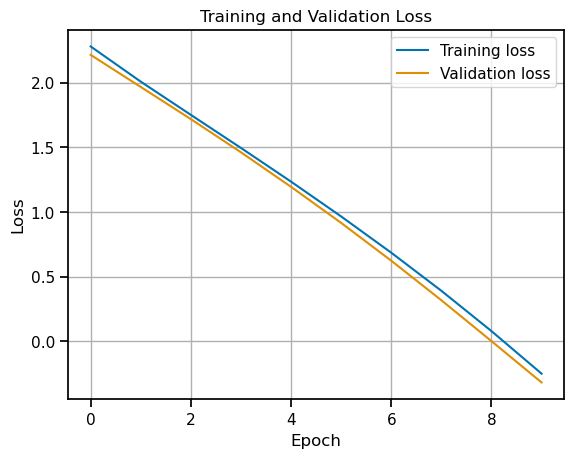

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history["training_loss"], label="Training loss")
plt.plot(history["validation_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
print(flow)

CouplingNSF(
  (_transform): CompositeTransform(
    (_transforms): ModuleList(
      (0-3): 4 x PiecewiseRationalQuadraticCouplingTransform(
        (transform_net): ResidualNet(
          (initial_layer): Linear(in_features=2, out_features=32, bias=True)
          (blocks): ModuleList(
            (0-1): 2 x ResidualBlock(
              (context_layer): Linear(in_features=1, out_features=32, bias=True)
              (linear_layers): ModuleList(
                (0-1): 2 x Linear(in_features=32, out_features=32, bias=True)
              )
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (final_layer): Linear(in_features=32, out_features=11, bias=True)
        )
      )
    )
  )
  (_distribution): StandardNormal()
)


In [25]:
x = torch.tensor([[-4.0, -5.0]], dtype=torch.get_default_dtype(), device=device)

# conditional input (must be shape (N, 1))
c = torch.tensor([[0.0]], dtype=torch.get_default_dtype(), device=device)

# eval mode + no gradients
flow.eval()
with torch.no_grad():
    logp = flow.log_prob(x, conditional=c)   # <-- key call
    p = torch.exp(logp)

print("log density =", logp.item())
print("density     =", p.item())

log density = -22.444650650024414
density     = 1.78818349017007e-10


In [27]:
import h5py
from copy import deepcopy
data_on = {}
data_off = {}
with h5py.File("../Sampling/Test.hdf", "r") as f:
    ifos = list(f.attrs["ifos"])
    ref_ifo = ifos[0]
    other_ifos = deepcopy(ifos)
    other_ifos.remove(ref_ifo)
    relfac = f.attrs["sensitivity_ratios"]
    keys = []
    for ifo in other_ifos:
        keys.extend([
            f"dt_{ifo}",
            f"dp_{ifo}",
            f"sr_{ifo}"
        ])
    for key in keys:
        data_on[f"{key}"] = f[ref_ifo]["param_bin_on"][key][:]
        data_off[f"{key}"] = f[ref_ifo]["param_bin_off"][key][:]
    print(data_on)
    print(data_off)
# Organise data and give bounds used.
data_array_on = np.array([v for v in data_on.values()]).T
data_array_off = np.array([v for v in data_off.values()]).T

{'dt_V1': array([-0.01601164,  0.01491154, -0.02385332, ...,  0.0139799 ,
       -0.0029947 , -0.01229377], dtype=float32), 'dp_V1': array([6.144571 , 0.673492 , 0.7531459, ..., 2.8599627, 3.409628 ,
       2.8691943], dtype=float32), 'sr_V1': array([-0.06652148, -0.24161349, -0.23831387, ..., -0.16451024,
       -0.10458241, -0.15416962], dtype=float32)}
{'dt_V1': array([ 0.01200762, -0.00592878, -0.01036713, ..., -0.02921654,
       -0.02366348,  0.00207624], dtype=float32), 'dp_V1': array([4.253418  , 3.8678925 , 2.1297548 , ..., 5.50064   , 0.16736916,
       1.0538661 ], dtype=float32), 'sr_V1': array([-5.0803530e-01, -8.3158612e-01, -9.3984973e-01, ...,
       -1.6849956e-01,  4.9438968e-04, -6.1172372e-01], dtype=float32)}


In [28]:
from ml_stat_DD import MLStatistic
from ml_stat_DD import NormalizingFlow

In [31]:
def create_bounds(data_on, data_off):
    # Both should have the same number of dimensions
    n_dims = data_on.shape[1]
    bounds = []
    smin = np.array([])
    smax = np.array([])
    
    for i in range(n_dims):
        # Calculate the global min/max across both arrays for this dimension
        global_min = min(data_on[:, i].min(), data_off[:, i].min())
        global_max = max(data_on[:, i].max(), data_off[:, i].max())
        
        if i % 3 == 1:  # Phase parameter
            bounds.append([0, 2*np.pi])
            
        elif i % 3 == 2: # Signal ratio parameter
            # Use the global min/max for the bounds
            bounds.append([global_min - 1e-6, global_max + 1e-6])
            
            # Use global min/max for the exponential scaling
            smin = np.append(smin, np.exp(global_min - 1e-6))
            smax = np.append(smax, np.exp(global_max + 1e-6))
            
        else: # Time parameter
            bounds.append([global_min - 1e-6, global_max + 1e-6])
    
    return np.array(bounds, dtype=np.float32), smin, smax

In [32]:
bounds, smin, smax = create_bounds(data_array_on, data_array_off)

In [33]:
if len(ifos) == 2:
        flow = NormalizingFlow(len(keys), bounds=bounds, n_neurons=10, num_bins=4)
        history = flow.fit(data_array_on, data_array_off, n_samples=10000)

100%|██████████| 100/100 [00:04<00:00, 20.05it/s]


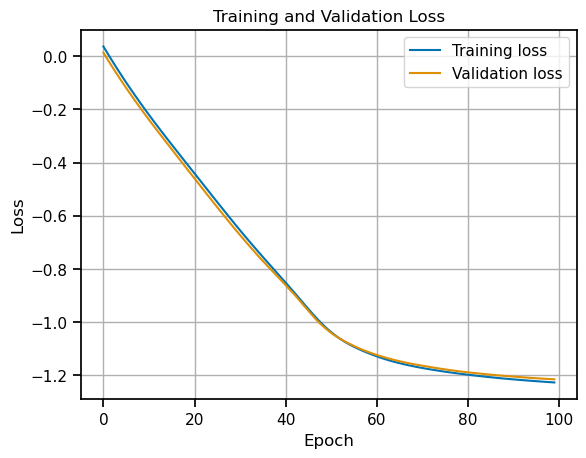

In [34]:
plt.figure()
plt.plot(history["training_loss"], label="Training loss")
plt.plot(history["validation_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
Test = np.array([[0, 2.28, np.log(1)]], dtype=np.float64)
cond = np.array([[1]], dtype=np.float64)

In [40]:
flow.log_prob(Test, conditional=cond)

array([0.68076134], dtype=float32)

In [128]:
import argparse, h5py, numpy as np, pycbc.detector, logging
from numpy.random import uniform, normal
from copy import deepcopy
from collections import defaultdict
d = {ifo: pycbc.detector.Detector(ifo) for ifo in ["L1", "H1"]}

size=1000000


# Use the first detector as a reference. The reference ifo is used 
# to get the correct symmetries when measuring dt, dp and sr for the triggers.

ifo0 = "L1"
other_ifos = deepcopy(["L1", "H1"])
other_ifos.remove(ifo0)
counts = defaultdict(list)


all_keys = []


# Choose random sky location and polarizations from
# an isotropic population. Distance is drawn from a 
# squared power law distribution. D_max is chosen 
# such that the SNR tail is normlaized to commonly 
# commonly used values.
ra = uniform(0, 2 * np.pi, size=size)
dec = np.arccos(uniform(-1., 1., size=size)) - np.pi/2
inc = np.arccos(uniform(-1., 1., size=size))
pol = uniform(0, 2 * np.pi, size=size)
ic = np.cos(inc)
ip = 0.5 * (1.0 + ic * ic)
D_max=0.6 * np.min([1.0,0.94])
uniform_random = np.random.uniform(0, 1, size=size)
distance = D_max * (uniform_random)**(1/3) 


# calculate the toa, poa, and amplitude of each sample,
# including uncertainties in measurements.
data = {}
for rs, ifo in zip([1.0, 0.94], ["L1", "H1"]):
    data[ifo] = {}
    fp, fc = d[ifo].antenna_pattern(ra, dec, pol, 0)
    sp, sc = fp * ip, fc * ic
    snr_sp = (rs*sp/distance) 
    snr_sc = (rs*sc/distance) 
    fsize = snr_sp.shape
    # Add noise to the SNR measurements
    normal_sp = normal(scale=1, size=fsize)
    normal_sc = normal(scale=1, size=fsize)
    snr_sp += normal_sp
    snr_sc += normal_sc
    data[ifo]['snr'] = (snr_sp**2+snr_sc**2)**0.5
    # Add noise to the phase and time measurements
    # Values obtained from modelling time and phase unc, t_unc given by Fairhurst 2009
    p_unc = 2.2/data[ifo]['snr']
    t_unc = 1/(2*np.pi*30*data[ifo]['snr'])
    rho = 0.8
    # Cholensky Decomposition
    l22_factor = np.sqrt(1.0 - rho**2)
    z_p = normal(size=fsize)
    z_t = normal(size=fsize)
    normal_dp = p_unc * z_p
    normal_dt = (rho * t_unc * z_p) + (t_unc * l22_factor * z_t)
    data[ifo]['p'] = (np.arctan2(snr_sc, snr_sp) + normal_dp) % (2. * np.pi)
    data[ifo]['t'] = d[ifo].time_delay_from_earth_center(ra, dec, 0) + normal_dt
    

# Organise the data
bind = []
bind2 = []
keep = None
for ifo1 in other_ifos:
    dt = (data[ifo0]['t'] - data[ifo1]['t'])
    dp = (data[ifo0]['p'] - data[ifo1]['p']) % (2. * np.pi)
    sr = np.log(data[ifo1]['snr'] / data[ifo0]['snr'])
    dtbin = dt
    dpbin = dp
    srbin = sr
    bind += [dtbin, dpbin, srbin]

snr_ref = data["L1"]['snr']
bind += [snr_ref]
bind2 += [snr_ref]

snrs_sq=np.zeros(len(data[ifo0]['snr']))
for ifo in ["L1","H1"]:
    snrs_sq += data[ifo]['snr']**2
net_snr = snrs_sq**0.5
    

# Applying thresholding, individual detector SNR > 4,

keep = None 
for ifo in ["L1", "H1"]:
    if keep is None:
        keep = (data[ifo]['snr']>= 4 ) 
    else:
        keep = keep & (data[ifo]['snr']>= 4 ) 
      

#Calculate and sum the weights for each bin
# use first ifo as reference for weights
bind = [a[keep] for a in bind]
bind2 = [a[keep] for a in bind2]

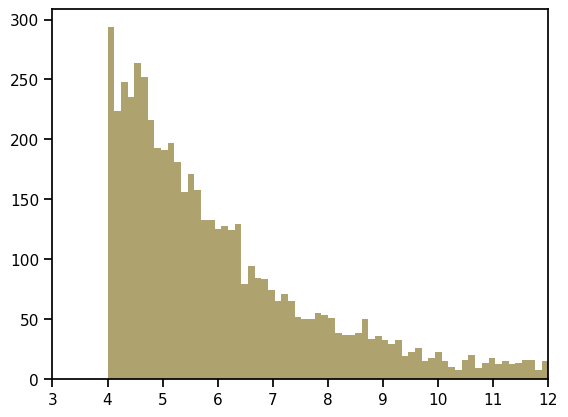

In [131]:
plt.hist(bind[3], bins=500, alpha=0.5, density=False, label="snr")
plt.hist(bind2[0], bins=500, alpha=0.5, density=False, label="snr")
# plt.hist(samples, bins=100, range=(4, 20), density=True, alpha=0.6, label='Samples')
plt.xlim(3,12)
plt.show()

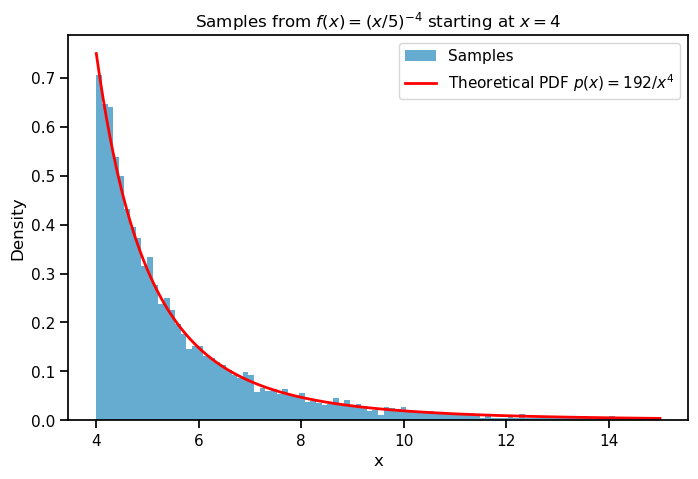

Sample mean: 5.9419
Theoretical mean: 6.0


In [90]:
import numpy as np
import matplotlib.pyplot as plt

def sample_custom_pdf(n_samples, x_min=4):
    """
    Samples from p(x) proportional to (x/5)^-4 for x >= x_min
    Using inverse transform: x = x_min * (1 - u)^(-1/3)
    """
    u = np.random.uniform(0, 1, n_samples)
    return x_min * (1 - u)**(-1/3)

# Generate 10,000 samples
n_samples = 10000
samples = sample_custom_pdf(n_samples)

# Verification Plot
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=100, range=(4, 15), density=True, alpha=0.6, label='Samples')

# Overlay theoretical PDF
x = np.linspace(4, 15, 500)
pdf = 192 / x**4
plt.plot(x, pdf, 'r-', lw=2, label='Theoretical PDF $p(x) = 192/x^4$')

plt.title('Samples from $f(x) = (x/5)^{-4}$ starting at $x=4$')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()

print(f"Sample mean: {np.mean(samples):.4f}")
print(f"Theoretical mean: 6.0") # E[x] = (alpha-1) * x_min / (alpha-2)